# Star Tracker Error Analysis and Visualization

This notebook provides a step-by-step guide to working with Star Tracker data. It covers the entire process, from downloading the data to performing error analysis and visualization. Specifically, it will:

- Download Star Tracker data from Rubin TV, selecting specific observation dates.
- Transfer the data to USDF for further processing.
- Read and extract information from the downloaded files.
- Analyze and visualize azimuth errors to assess the accuracy of Star Tracker observations.


## Downloading Star Tracker Data  

To analyze the stars tracked, the first step is to access Rubin TV for download the using the following link:  
[Rubin TV - Summit USDF](https://usdf-rsp.slac.stanford.edu/rubintv/summit-usdf)  

Once on the Rubin TV page, you can access data from **StarTracker Narrow**, **StarTracker Wide**,
or **StarTracker Fast** by clicking on the corresponding icons.  

### Selecting a Specific Date  

To search for data from a specific observation day, click on the **Historical** botton.  

You can use the calendar to select the year, month, and day of the data you want to analyze. Suppose we want to download data from **November 23, 2022**. Click on the calendar to select this date.  

Once the date is selected, the available data for that day will be displayed.  

### Downloading the Data  

To download the data, click on **Download Metadata**, and a `.json` file containing the information will be downloaded. In this case, the file will be named: startracker_narrow_2022-11-23.json

## Transferring Data to USDF  

Now that the data is stored on your local computer, you need to copy it to USDF to be able to use it.  

### Uploading Data to USDF  

To do this, you can create a folder named **starTracker** inside your `notebooks/` directory and upload the data there. However, you can also place the data in any other directory of your choice.  

### Copying Data to Scratch Directory  

For better accessibility and performance, it is recommended to store the data in the **scratch directory**. You can copy the uploaded files to:  `/scratch/users/<your_username>/starTracker`

Before doing so, make sure that the `starTracker` folder exists inside your user directory. If it does not exist, create it first using:  

```bash
mkdir -p /scratch/users/<your_username>/starTracker
```

Now, you can copy the files from notebooks/starTracker/ to the scratch directory by running the following command in the terminal:

```bash
cp /home/<your_username>/notebooks/starTracker/* /scratch/users/<your_username>/starTracker/
```

This will move all the files you uploaded into the starTracker folder in the scratch directory, making them ready for analysis.

We are now ready to start the analysis

In [1]:
from datetime import date, datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.time import Time, TimeDelta

## Reading and Processing Star Tracker Data

In [2]:
# Modify this path to your own directory where the data is stored  
# Example: DATA_DIR = "/scratch/users/<your_username>/starTracker"
DATA_DIR = "/scratch/users/t/toribio/starTracker"

def read_rubin_tv_json(day_obs, camera):
    """
    Reads a RubinTV JSON file for the given observation day and camera.

    Parameters:
    ----------
    day_obs : int
        Observation day in the format YYYYMMDD.
    camera : str
        Camera type: 'Wide', 'Narrow', or 'AuxTel'.

    Returns:
    -------
    pd.DataFrame
        Transposed DataFrame containing the JSON data.
    """
    # Convert day_obs to datetime and then to astropy Time
    time_obj = Time(datetime.strptime(str(day_obs), "%Y%m%d"))
    date_str = time_obj.strftime("%Y-%m-%d")

    # Define filename based on camera type
    filename_map = {
        "Wide": f"{DATA_DIR}/startracker_wide_{date_str}.json",
        "Narrow": f"{DATA_DIR}/startracker_narrow_{date_str}.json",
        "AuxTel": f"{DATA_DIR}/auxtel_{date_str}.json",
        "Fast": f"{DATA_DIR}/startracker_fast_{date_str}.json",
    }

    filename = filename_map.get(camera)

    if not filename:
        raise ValueError(f"Invalid camera type: {camera}")

    try:
        df = pd.read_json(filename).transpose()
        print(f"Loaded file: {filename}")
        return df
    except FileNotFoundError:
        print(f"Error: File not found - {filename}")
        return None

In [3]:
# List of observation dates in YYYYMMDD format
# Modify this list with your own data
dates = [
    20221123, 20221124, 20221128, 20221207, 20230130, 
    20230220, 20230221, 20230222, 20230307, 20230308, 20230309
]

# Select the type of camera between three options: Narrow, Wide and Fast
camera = "Narrow" # "Wide"  "Fast" "Narrow"
# num = 102

# Variables to store results
x_axis = []
delta_azs = []
delta_els = []
counter = 1

for day_obs in dates:

    # Read data from RubinTV JSON files
    df = read_rubin_tv_json(day_obs, camera)
    if df is None:
        continue  # Skip if the file does not exist
        
    # Remove rows with NaN values
    df = df.dropna()

    for seq_num, row in df.iterrows():
        if camera == "Narrow":
            alt_col = "Delta Alt Arcsec"
            az_col = "Delta Az Arcsec"
        elif camera == "Wide":
            alt_col = "Delta Alt Arcsec wide"
            az_col = "Delta Az Arcsec wide"
        else:
            continue 
        if alt_col in df.columns and az_col in df.columns:
            delta_alt = row[alt_col]
            delta_az = row[az_col]
            
            delta_azs.append(abs(delta_az))
            delta_els.append(abs(delta_alt))
         
            if day_obs < 20230309 or (day_obs == 20230309 and seq_num <= 1138):
                x_axis.append(counter)

            elif day_obs == 20230309 and seq_num > 1138:
                x_axis.append(counter + 1)
                
    counter += 1


Loaded file: /scratch/users/t/toribio/starTracker/startracker_narrow_2022-11-23.json
Loaded file: /scratch/users/t/toribio/starTracker/startracker_narrow_2022-11-24.json
Loaded file: /scratch/users/t/toribio/starTracker/startracker_narrow_2022-11-28.json
Loaded file: /scratch/users/t/toribio/starTracker/startracker_narrow_2022-12-07.json
Loaded file: /scratch/users/t/toribio/starTracker/startracker_narrow_2023-01-30.json
Loaded file: /scratch/users/t/toribio/starTracker/startracker_narrow_2023-02-20.json
Loaded file: /scratch/users/t/toribio/starTracker/startracker_narrow_2023-02-21.json
Loaded file: /scratch/users/t/toribio/starTracker/startracker_narrow_2023-02-22.json
Loaded file: /scratch/users/t/toribio/starTracker/startracker_narrow_2023-03-07.json
Loaded file: /scratch/users/t/toribio/starTracker/startracker_narrow_2023-03-08.json
Loaded file: /scratch/users/t/toribio/starTracker/startracker_narrow_2023-03-09.json


## Visualise the data

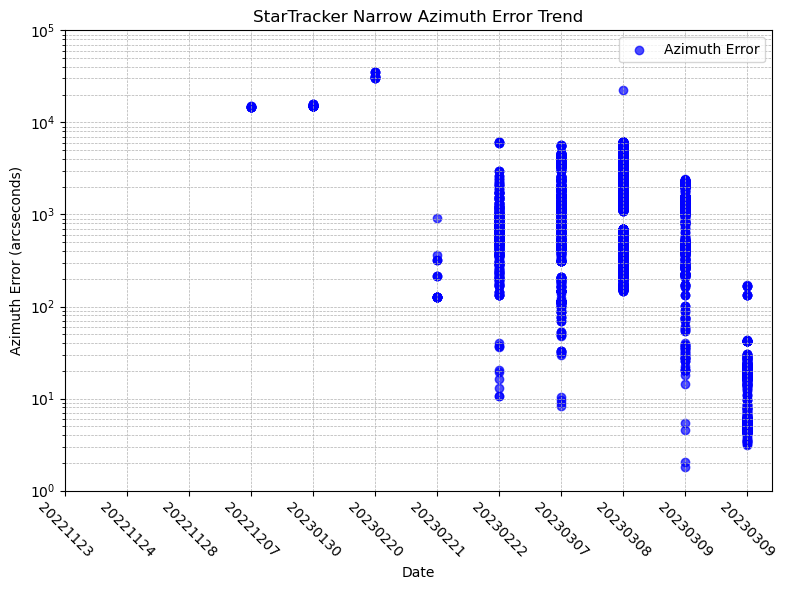

In [4]:
# Extend dates list to include the last observation date
plot_dates = dates + [20230309]

# Define x-axis ticks
x_ticks = np.arange(1, len(plot_dates) + 1, 1)

# Create the plot for StarTracker Narrow Azimuth Error Trend
plt.figure(figsize=(8, 6))
plt.title("StarTracker Narrow Azimuth Error Trend")

# Scatter plot of azimuth errors
plt.scatter(x_axis, delta_azs, color="blue", alpha=0.7, label="Azimuth Error")

# Use logarithmic scale for the y-axis
plt.yscale("log")
plt.ylim(1.0, 1.0e5)

# Set x-axis labels with proper rotation
plt.xticks(x_ticks, plot_dates, rotation=-45)

# Label axes
plt.xlabel("Date")
plt.ylabel("Azimuth Error (arcseconds)")

# Show grid and legend for better readability
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.legend()
plt.tight_layout()

# Display the plot
plt.show()


In [ ]:
# List of observation dates in YYYYMMDD format
dates = [
    20221123, 20221124, 20221128, 20221207, 20230130, 
    20230220, 20230221, 20230222, 20230307, 20230308, 20230309
]

camera = "Narrow"# "Wide"  "Fast" "Narrow"
num = 102

# Variables to store results
x_axis = []
delta_azs = []
delta_els = []
counter = 1

for day_obs in dates:
    
    if day_obs < 0:# 20230220:
        # Read data from old StarTracker files
        data = read_rubin_tv_json(day_obs,camera)
        if data is None:
            continue  # Skip if the file does not exist
    
        for seq_num, row in data.iterrows():
         
           if camera == "Narrow":
              alt_col = "Delta Alt Arcsec"
              az_col = "Delta Az Arcsec"
           elif camera == "Wide":
              alt_col = "Delta Alt Arcsec wide"
              az_col = "Delta Az Arcsec wide"
           else:
              continue  
        
           if alt_col in data.columns and az_col in data.columns:
              delta_alt = row[alt_col]
              delta_az = row[az_col]
              
              x_axis.append(counter)
              delta_azs.append(abs(delta_az))  
              delta_els.append(abs(delta_alt)) 


        else:
           counter += 1
           continue  

    else:
        # Read data from RubinTV JSON files
        df = read_rubin_tv_json(day_obs, camera)
        if df is None:
            continue  # Skip if the file does not exist
        
        # Remove rows with NaN values
        df = df.dropna()

        for seq_num, row in df.iterrows():
            if camera == "Narrow":
               alt_col = "Delta Alt Arcsec"
               az_col = "Delta Az Arcsec"
            elif camera == "Wide":
               alt_col = "Delta Alt Arcsec wide"
               az_col = "Delta Az Arcsec wide"
            else:
               continue 
        
            if alt_col in df.columns and az_col in df.columns:
               delta_alt = row[alt_col]
               delta_az = row[az_col]
         
            #delta_alt = row["Delta Alt Arcsec"]
            #delta_az = row["Delta Az Arcsec"]
            if day_obs < 20230309 or (day_obs == 20230309 and seq_num <= 1138):
                x_axis.append(counter)
                   #delta_alt = row[alt_col]
                   #delta_az = row[az_col]
            elif day_obs == 20230309 and seq_num > 1138:
                x_axis.append(counter + 1)
                   #delta_alt = row[alt_col]
                   #delta_az = row[az_col]

            delta_azs.append(abs(delta_az))
            delta_els.append(abs(delta_alt))

    counter += 1


In [ ]:
# TODO: Preguntar por la nueva ubicación de los archivos
DATA_DIR = ""#"/path/to/correct/directory"

def read_rubin_tv_json_(day_obs, camera):
    """
    Reads a RubinTV JSON file for the given observation day and camera.

    Parameters:
    ----------
    day_obs : int
        Observation day in the format YYYYMMDD.
    camera : str
        Camera type: 'Wide', 'Narrow', or 'AuxTel'.

    Returns:
    -------
    pd.DataFrame
        Transposed DataFrame containing the JSON data.
    """
    # Convert day_obs to ISO format using astropy
    time_obj = getDayObsStartTime(day_obs)
    date_str = time_obj.strftime("%Y-%m-%d")

    # Define filename based on camera type
    filename_map = {
        "Wide": f"{DATA_DIR}/startracker-wide_{date_str}.json",
        "Narrow": f"{DATA_DIR}/startracker_{date_str}.json",
        "AuxTel": f"{DATA_DIR}/auxtel_{date_str}.json",
    }

    filename = filename_map.get(camera)
    if not filename:
        raise ValueError(f"Invalid camera type: {camera}")

    try:
        df = pd.read_json(filename).transpose()
        print(f"Loaded file: {filename}")
        return df
    except FileNotFoundError:
        print(f"Error: File not found - {filename}")
        return None


def read_old_star_tracker_files(day_obs, camera):
    """
    Reads an old-style Star Tracker summary file.

    Parameters:
    ----------
    day_obs : int
        Observation day in the format YYYYMMDD.
    camera : str
        Camera type.

    Returns:
    -------
    np.array
        Data array from the file.
    """
    filename = f"{DATA_DIR}/StarTracker_Summary_{camera}_{day_obs}.txt"

    try:
        data = np.loadtxt(filename, skiprows=1)
        print(f"Loaded file: {filename}")
        return data
    except FileNotFoundError:
        print(f"Error: File not found - {filename}")
        return None


In [ ]:
pwd

In [ ]:
/scratch/users/t/toribio

In [ ]:
def  readRubinTV_json(date, camera):
    year = int(date/10000)
    month = int((date - 10000 * year)/100)
    day = int((date - 10000 * year - 100 * month))
    if camera == 'Wide':
        filename = f'/scratch/cslage/starTracker/startracker-wide_{year}-{month:02}-{day:02}.json'
    elif camera == 'Narrow':
        filename = f'/scratch/cslage/starTracker/startracker_{year}-{month:02}-{day:02}.json'
    elif camera == 'AuxTel':
        filename = f'/scratch/cslage/starTracker/auxtel_{year}-{month:02}-{day:02}.json'
    df = pd.read_json(filename)
    df = df.transpose()
    print(filename)
    return df

def readOldStarTrackerFiles(date, camera):
        filename = f"/scratch/cslage/starTracker/StarTracker_Summary_{camera}_{date}.txt"
        data = np.loadtxt(filename, skiprows=1)
        return data


In [ ]:
[camera, num] = ['Narrow', 102]
xaxis = []
deltaazs = []
deltaels = []
dates = [20221123, 20221124, 20221128, 20221207, 20230130, 20230220,  20230221, 20230222, 20230307, 20230308, 20230309]
counter = 1
for date in dates:
    year = int(date/10000)
    month = int((date - 10000 * year)/100)
    day = int((date - 10000 * year - 100 * month))
    if date < 20230220:
        data = readOldStarTrackerFiles(date, camera)
        for j in range(data.shape[0]):
            [seqNum,ra,dec,raSolve,decSolve,Az,El,azSolve,elSolve,deltaAz,deltaEl,\
             rot,rms_error] = data[j]
            xaxis.append(counter)
            deltaazs.append(abs(deltaAz) * 3600.0)
            deltaels.append(abs(deltaEl) * 3600.0)
    else:
        df = readRubinTV_json(date, camera)
        df = df[~df.isnull().any(axis=1)]
        for seqNum in df.index.values.tolist():
            row = df.loc[seqNum]
            deltaAlt = row['Delta Alt Arcsec']
            deltaAz = row['Delta Az Arcsec']
            if date < 20230309 or (date == 20230309 and seqNum < 1138):
                xaxis.append(counter)
                deltaazs.append(abs(deltaAz))
                deltaels.append(abs(deltaAlt))
            if date == 20230309 and seqNum > 1138:
                xaxis.append(counter + 1)
                deltaazs.append(abs(deltaAz))
                deltaels.append(abs(deltaAlt))
                
    counter += 1


In [ ]:
len(xaxis)

In [ ]:
plot_dates = dates + [20230309]
xticks = np.arange(1,13,1)
plt.title("StarTracker Narrow Azimuth Error Trend")
plt.scatter(xaxis, deltaazs)
plt.yscale('log')
plt.ylim(1.0, 1.0E5)
plt.xticks(xticks, plot_dates, rotation=-45)
plt.xlabel("Date")
plt.ylabel("Azimuth Error (arcseconds)")
